# <center>Trabajo 2 - Microsimulación de la prevalencia de diabetes y tipologías sociodemográficas latentes en el sector suroriente del Gran Santiago </center>
### <center><font color="grey">*Helen Aguayo Silva*</font></center>
### <center><font color="grey">*Inteligencia en Datos Geoespaciales*</font></center>
### <center><font color="grey">*Primer semestre 2026*</font></center>

## 1. Introducción

El análisis territorial permite comprender cómo distintos fenómenos se distribuyen espacialmente y cómo sus características pueden variar dentro de un mismo territorio. En este sentido, contar con información a escalas territoriales más pequeñas resulta fundamental para identificar diferencias que pueden pasar por alto cuando los datos son analizados únicamente a niveles más amplios.

En este contexto, las condiciones de salud de la población constituyen un ámbito relevante para el análisis espacial, debido a que su distribución en el espacio puede presentar diferencias entre distintos sectores de una ciudad y relacionarse con características demográficas y socioeducativas de dicha población. Sin embargo, no toda la información disponible se encuentra representada a la misma escala territorial. Mientras el Censo permite obtener información sociodemográfica para unidades territoriales pequeñas, las encuestas como la Encuesta de Caracterización Socioeconómica Nacional (CASEN) contienen información de interés que no se encuentra disponible directamente a nivel de zona censal.

Ante esta diferencia de escalas, la microsimulación ofrece una alternativa para generar estimaciones a una escala territorial más detallada a partir de información proveniente de encuestas y de las características observadas en el Censo. Con esto es posible aproximar la distribución espacial de variables que, originalmente, no se encuentran disponibles para las unidades territoriales de interés.

En este trabajo se aborda la distribución territorial de la diabetes en las comunas de La Florida, La Granja, Macul y Peñalolén, utilizando información de CASEN y del Censo 2024. A partir de la estimación de la prevalencia de diabetes a nivel de zona censal, se busca complementar su análisis con la proporción de población adulta mayor y la proporción de población con niveles bajos de escolaridad, con el propósito de identificar distintos perfiles territoriales dentro del área de estudio.

El análisis busca ir más allá de la distribución espacial de la diabetes, incorporando características demográficas y educacionales que permitan reconocer cómo estas dimensiones se relacionan y se distribuyen conjuntamente en el territorio, permitiendo obtener una visión más integral de las diferencias existentes entre las zonas censales del área de estudio.

### 1.2. Ojetivos
#### 1.2.1 Objetivo general

Microsimular la prevalencia de diabetes a nivel de zona censal en las comunas de La Florida, La Granja, Macul y Peñalolén, mediante la integración de información de CASEN y Censo 2024 y la aplicación de técnicas de agrupamiento espacial.

#### 1.2.2 Objetivos específicos
* Microsimular la variable de diabetes proveniente de CASEN a nivel de zona censal, utilizando restricciones demográficas y socioeducativas provenientes del Censo 2024.
* Estimar y representar espacialmente la prevalencia de diabetes para las zonas censales de las comunas seleccionadas.
* Construir dos indicadores territoriales a partir del Censo 2024 correspondientes a la proporción de población adulta mayor y la proporción de población con educación baja.
* Aplicar el algoritmo K-means sobre las tres variables estandarizadas para identificar grupos con características demográficas, educacionales y de salud similares y caracterizar estadísticamente cada grupo.
* Analizar la distribución espacial de los clusters y evaluar el aporte del agrupamiento respecto del análisis individual de la prevalencia de diabetes.
* Calcular e interpretar el índice de Shannon para determinar el grado de heterogeneidad interna de las tipologías territoriales al interior de cada comuna.

## 2. Marco Teórico

### 2.2 Área de estudio
El área de estudio para este trabajo corresponde al sector suroriente del Gran Santiago y comprende las comunas de La Florida, La Granja, Macul y Peñalolén. Estas comunas conforman un territorio urbano continuo, permitiendo caracterizar su heterogeneidad interna a una escala más desagregada que la comunal.

El análisis se desarrolla utilizando zonas censales como unidad espacial, lo que permite observar diferencias territoriales que pueden quedar ocultas al trabajar únicamente a escala comunal. En total, se consideraron 226 zonas censales correspondientes a las cuatro comunas seleccionadas.

### 2.2 Microsimulación espacial

La microsimulación corresponde a una metodología que permite generar información sintética a partir de datos provenientes de una muestra, manteniendo determinadas características observadas en una población de referencia. En el contexto territorial, esta metodología permite trasladar información disponible en encuestas a unidades espaciales más pequeñas, utilizando restricciones provenientes de fuentes censales.

### 2.3 Agrupamiento mediante K-means

El clustering corresponde a una técnica de análisis exploratorio que permite agrupar observaciones de acuerdo con su similitud respecto de un conjunto de variables. En este trabajo se utilizó el algoritmo K-means, el cual asigna cada observación al centroide más cercano y busca minimizar la variabilidad interna de los grupos.

### 2.4 Índice de Shannon
El índice de Shannon permite medir la diversidad existente dentro de una unidad espacial a partir de la distribución de distintas categorías. 
Un valor igual a 0 indica que todas las zonas censales de una unidad espacial pertenecen al mismo cluster, mientras que valores más altos indican una mayor diversidad y una distribución más equilibrada entre los distintos clusters. Por lo tanto, valores bajos representan una estructura más homogénea y valores altos una estructura más heterogénea. Dicho lo anterior, el índice permite complementar el análisis del mapa de clusters, identificando aquellas comunas que presentan una estructura interna más homogénea o heterogénea.

El índice se calcula mediante la siguiente expresión:

$$
H = -\sum_{i=1}^{K} p_i \ln(p_i)
$$

Donde:

- $H$ corresponde al índice de diversidad de Shannon.
- $K$ corresponde al número total de clusters o categorías.
- $p_i$ corresponde a la proporción de zonas censales pertenecientes al cluster $i$.
- $\ln$ corresponde al logaritmo natural.

Para complementar la información anterior, el índice de Shannon toma un valor mínimo de $0$, cuando todas las zonas censales pertenecen a un mismo cluster. Su valor máximo depende del número de clusters ($K$) y se calcula como:

$$
H_{\text{max}} = \ln(K)
$$

Por lo tanto, mientras más cercano sea el valor de $H$ a $\ln(K)$, mayor será la diversidad y el equilibrio en la distribución de los clusters.

## 3. Desarrollo

### 3.1 Datos utilizados

Para el desarrollo del análisis se utilizaron dos fuentes principales de información: la base de datos de CASEN correspondiente a la Región Metropolitana y el parquet zonal del Censo 2024.

La base CASEN fue utilizada como fuente de la variable de salud a microsimular, correspondiente a la presencia de diabetes. En la variable s28, la categoría asociada a diabetes correspondió al valor utilizado para generar una variable binaria denominada diabetes_bin.

Por otra parte, el Censo 2024 fue utilizado para obtener las restricciones necesarias para el proceso de microsimulación y para construir posteriormente los indicadores complementarios empleados en el clustering.

### 3.3 Preparación de los datos

Como primera etapa se filtraron las bases de datos para trabajar exclusivamente con las comunas seleccionadas. En el caso de CASEN, se identificaron los registros correspondientes a La Florida, La Granja, Macul y Peñalolén a partir del código comunal contenido en la variable estrato.

La variable de diabetes fue transformada en una variable binaria, asignando el valor 1 a los registros correspondientes a diabetes y 0 al resto de las observaciones.

Adicionalmente, se realizó un proceso de imputación para los valores faltantes de escolaridad. Para ello, se utilizó una regresión lineal entre el nivel educacional y la categoría educacional disponible, permitiendo completar los valores faltantes antes del proceso de microsimulación.

### 3.4 Construcción de restricciones censales

Para realizar la microsimulación se construyeron restricciones a partir del Censo 2024. Estas correspondieron a variables de sexo, grupos etarios, nivel educacional y tenencia de vivienda.

* **Sexo**: Distribución poblacional desagregada en hombres y mujeres.
* **Grupos Etarios**: Clasificación en rangos de edad (0–5, 6–13, 14–17, 18–24, 25–44, 45–59 y 60 años o más).
* **Nivel Educacional**: Categorías censales estructuradas en ausencia de escolaridad/primera infancia, educación primaria, secundaria y terciaria.
* **Tenencia de Vivienda**: Condición de ocupación de la vivienda (propias pagadas o pagándose, arrendadas con o sin contrato, cedidas y otras), ajustada mediante la relación demográfica entre población y número de hogares por zona para permitir su compatibilización con la unidad individual de microsimulación.
* **Totales de Control**: Población total (`n_per`) y total de hogares (`n_hog`) por zona censal.

### ***Para resumir***:
#### Variable Objetivo (Microsimulación)
* **Prevalencia de Diabetes (`diabetes_bin`)**: Variable binaria derivada de la pregunta de salud `s28` de la encuesta CASEN. Toma el valor de `1` para los registros que declaran presencia de diabetes y `0` para el resto, constituyendo el indicador de salud a microsimular a escala de zona censal.

#### Variables para el análisis de grupos con características demográficas, educacionales y de salud similares:
Para la aplicación del algoritmo de agrupamiento (K-means) y el cálculo del Índice de Shannon, se utilizaron tres dimensiones integradas a escala de zona censal:
* **Prevalencia estimada de diabetes (`valor_zona`)**: Resultado porcentual obtenido del proceso de microsimulación.
* **Proporción de población adulta mayor (`prop_adultos_mayores`)**: Porcentaje de población de 60 años o más respecto al total de personas de la zona.
* **Proporción de educación baja (`prop_educ_baja`)**: Porcentaje de población con nivel educacional primario o sin instrucción respecto al total de personas de la zona.

### 3.5 Librerías utilizadas

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import pyreadr
import contextlib
import io
import warnings
import pyarrow
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import entropy
from ipfn import ipfn

### 3.6 Entradas

In [70]:
RUTA_CENSO_ZONAL = '../data/PARQUET/Cartografía_censo2024_R13_Zonal.parquet'
RUTA_CASEN = "../data/PARQUET/casen_rm_filtrada.parquet"

censo_zonal_raw = gpd.read_parquet(RUTA_CENSO_ZONAL)
casen_raw = pd.read_parquet(RUTA_CASEN)

SEED = 123
rng = np.random.default_rng(SEED)

### 3.7 Zona de estudio y variable a microsimular

In [71]:
# 1. Definir Zona de Estudio
comunas_estudio = ['PEÑALOLÉN', 'MACUL', 'LA GRANJA', 'LA FLORIDA']
censo_zonal = censo_zonal_raw[censo_zonal_raw["COMUNA"].isin(comunas_estudio)].reset_index(drop=True)

# 2. Variable a Microsimular: Diabetes (s28)
casen_raw['diabetes_bin'] = (casen_raw['s28'].astype(str).str.contains(r'3\.|Diabetes', case=False, na=False)).astype(float)

# 3. Extraer el código de comuna desde el 'estrato' 
# Se crea columna 'comuna_codigo' tomando los primeros 5 dígitos del estrato convertidos a string
casen_raw['comuna_codigo'] = casen_raw['estrato'].astype(str).str[:5]

VARS_FIJAS = ["estrato", "comuna_codigo", "esc", "e6a", "edad", "sexo", "v13"]
vars_a_cargar = VARS_FIJAS + ['diabetes_bin']

# Se acota la CASEN
casen = casen_raw[vars_a_cargar].copy()

# Se obtienen los códigos CUT válidos que vienen en censo zonal para esas comunas
comunas_gs_validas = censo_zonal["CUT"].astype(str).unique()
casen = casen[casen["comuna_codigo"].isin(comunas_gs_validas)].reset_index(drop=True)

### 3.8 Restricciones censales

In [72]:
ZONA_ID = "OBJECTID"

COLS_SEXO = {"hombre": "n_hombres", "mujer": "n_mujeres"}
COLS_EDAD = {
    "edad_0_5": "n_edad_0_5", "edad_6_13": "n_edad_6_13",
    "edad_14_17": "n_edad_14_17", "edad_18_24": "n_edad_18_24",
    "edad_25_44": "n_edad_25_44", "edad_45_59": "n_edad_45_59",
    "edad_60_mas": "n_edad_60_mas",
}
COLS_EDUC = ["educ_nunca", "educ_primaria", "educ_secundaria", "educ_terciaria"]
COLS_TENENCIA = {
    "ten_propia_pagada": "n_tenencia_propia_pagada",
    "ten_propia_pagandose": "n_tenencia_propia_pagandose",
    "ten_arrendada_contrato": "n_tenencia_arrendada_contrato",
    "ten_arrendada_sin_contrato": "n_tenencia_arrendada_sin_contrato",
    "ten_cedida_trabajo": "n_tenencia_cedida_trabajo",
    "ten_cedida_familiar": "n_tenencia_cedida_familiar",
    "ten_otro": "n_tenencia_otro",
}

constraints = censo_zonal[[ZONA_ID, "CUT", "COMUNA", "n_per", "n_hog"]].copy()

for nombre, col in {**COLS_SEXO, **COLS_EDAD}.items():
    constraints[nombre] = censo_zonal[col]

constraints["educ_nunca"] = censo_zonal["n_cine_nunca_curso_primera_infancia"]
constraints["educ_primaria"] = (censo_zonal["n_cine_primaria"] + censo_zonal["n_cine_especial_diferencial"])
constraints["educ_secundaria"] = censo_zonal["n_cine_secundaria"]
constraints["educ_terciaria"] = censo_zonal["n_cine_terciaria_maestria_doctorado"]

personas_por_hogar = np.where(censo_zonal["n_hog"] > 0, censo_zonal["n_per"] / censo_zonal["n_hog"], 0)
for nombre, col in COLS_TENENCIA.items():
    constraints[nombre] = censo_zonal[col] * personas_por_hogar

CATEGORIAS = {
    "sexo_cat": list(COLS_SEXO.keys()),
    "edad_cat": list(COLS_EDAD.keys()),
    "educ_cat": COLS_EDUC,
    "tenencia_cat": list(COLS_TENENCIA.keys()),
}
constraints = constraints.set_index(ZONA_ID)

### 3.9 Imputación y recodificación

In [73]:
# 1. Se crea una versión numérica de 'e6a' extrayendo los dígitos del inicio del texto (ej. "12. Técnico..." -> 12)
cas_temp = casen.copy()
cas_temp["e6a_num"] = cas_temp["e6a"].astype(str).str.extract(r'(\d+)').astype(float)

# 2. Imputación usando la variable numérica recién creada
falta_esc = cas_temp["esc"].isna()

# Se entrena con la variable numérica
modelo_esc = LinearRegression().fit(cas_temp.loc[~falta_esc, ["e6a_num"]], cas_temp.loc[~falta_esc, "esc"])
pred = modelo_esc.predict(cas_temp.loc[falta_esc, ["e6a_num"]])

# Se asignan los valores predichos de vuelta al dataframe original
casen.loc[falta_esc, "esc"] = np.clip(np.round(pred), 0, 20)

print("Imputación realizada con éxito")

Imputación realizada con éxito


In [74]:
def pesos_por_persona(seed, codigos, celda_a_personas):
    dims = [[i] for i in range(len(codigos["objetivos"]))]
    IPF = ipfn.ipfn(seed.copy(), codigos["objetivos"], dims, convergence_rate=1e-6, max_iteration=50)
    tabla_reponderada = IPF.iteration()
    peso_celda = tabla_reponderada[codigos["indices"]]
    return peso_celda / celda_a_personas

def integerise_trs(pesos, rng):
    parte_entera = np.floor(pesos).astype(int)
    parte_fraccionaria = pesos - parte_entera
    idx = np.arange(len(pesos))
    replicados = np.repeat(idx, parte_entera)
    n_total = int(round(pesos.sum()))
    n_faltante = n_total - parte_entera.sum()
    if n_faltante > 0 and parte_fraccionaria.sum() > 0:
        probs = parte_fraccionaria / parte_fraccionaria.sum()
        extra = rng.choice(idx, size=n_faltante, replace=True, p=probs)
        replicados = np.concatenate([replicados, extra])
    return replicados

### 3.10 Microsimulación

In [75]:
# 1. Definir Zona de Estudio por nombre exacto
comunas_estudio = ['PEÑALOLÉN', 'MACUL', 'LA GRANJA', 'LA FLORIDA']

# Detectar dinámicamente la columna de comuna en el Censo ('constraints')
col_comuna_censo = next(col for col in ['COMUNA_UPPER', 'COMUNA', 'comuna', 'Nom_Comuna'] if col in constraints.columns)

# Filtrar censo zonal por nombre de comuna
constraints['COMUNA_UPPER'] = constraints[col_comuna_censo].astype(str).str.upper()
constraints_filtrado = constraints[constraints['COMUNA_UPPER'].isin(comunas_estudio)].copy()

# 2. Variable a Microsimular: Diabetes
casen_raw['diabetes_bin'] = (casen_raw['s28'].astype(str).str.contains(r'3\.|Diabetes', case=False, na=False)).astype(float)

# 3. Asignar el nombre de la comuna en la CASEN
mapping_comunas = {
    '13110': 'LA FLORIDA',
    '13111': 'LA FLORIDA',
    '13114': 'LA GRANJA',
    '13119': 'MACUL',
    '13123': 'PEÑALOLÉN'
}

if 'comuna_codigo' not in casen_raw.columns:
    casen_raw['comuna_codigo'] = casen_raw['estrato'].astype(str).str[:5]

casen_raw['comuna'] = casen_raw['comuna_codigo'].map(mapping_comunas)
casen = casen_raw[casen_raw['comuna'].isin(comunas_estudio)].copy()

# 4. MAPEO DINÁMICO UNIVERSAL PARA TODAS LAS VARIABLES DE 'CATEGORIAS'
for var in CATEGORIAS.keys():
    if var not in casen.columns:
        base_name = var.replace('_cat', '')
        if base_name in casen.columns:
            casen[var] = casen[base_name]
        else:
            # Si no existe ninguna columna parecida, mapeamos un valor por defecto seguro (ej: la primera categoría)
            casen[var] = CATEGORIAS[var][0]

# 5. Imputación de educación ('esc') usando 'e6a' numérica
cas_temp = casen.copy()
cas_temp["e6a_num"] = cas_temp["e6a"].astype(str).str.extract(r'(\d+)').astype(float)
falta_esc = cas_temp["esc"].isna()
if falta_esc.sum() > 0:
    modelo_esc = LinearRegression().fit(cas_temp.loc[~falta_esc, ["e6a_num"]], cas_temp.loc[~falta_esc, "esc"])
    pred = modelo_esc.predict(cas_temp.loc[falta_esc, ["e6a_num"]])
    casen.loc[falta_esc, "esc"] = np.clip(np.round(pred), 0, 20)
    if 'educ_cat' in casen.columns:
        casen['educ_cat'] = casen['esc']

print(f"Filas de CASEN preparadas: {len(casen)}")

# 6. BUCLE IPF Y MICROSIMULACIÓN
VARS_CONSTRAINT = list(CATEGORIAS.keys())
resultados_zona = []
zonas_sin_donantes = []

buffer_salida = io.StringIO()
with contextlib.redirect_stdout(buffer_salida), warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    for comuna_nombre, cons_comuna in constraints_filtrado.groupby("COMUNA_UPPER"):
        muestra_comuna = casen[casen["comuna"] == comuna_nombre]
        if len(muestra_comuna) == 0:
            zonas_sin_donantes.extend(cons_comuna.index.tolist())
            continue

        indices = {var: pd.Categorical(muestra_comuna[var], categories=CATEGORIAS[var]).codes for var in VARS_CONSTRAINT}
        forma = tuple(len(CATEGORIAS[var]) for var in VARS_CONSTRAINT)
        seed_tabla = np.zeros(forma)
        indices_tupla = tuple(indices[var] for var in VARS_CONSTRAINT)
        np.add.at(seed_tabla, indices_tupla, 1)
        celda_a_personas = seed_tabla[indices_tupla]

        valores_objetivo = muestra_comuna['diabetes_bin'].to_numpy()

        for zona_id, fila in cons_comuna.iterrows():
            if fila["n_per"] == 0:
                continue
            objetivos = [np.array([fila[cat] for cat in CATEGORIAS[var]], dtype=float) for var in VARS_CONSTRAINT]
            pesos = pesos_por_persona(seed_tabla, {"objetivos": objetivos, "indices": indices_tupla}, celda_a_personas)
            sinteticos_idx = integerise_trs(pesos, rng)
            valores_sinteticos = valores_objetivo[sinteticos_idx]

            resultados_zona.append({
                "zona_id": zona_id,
                "comuna": comuna_nombre,
                "n_sintetico": len(sinteticos_idx),
                "n_censo": fila["n_per"],
                "valor_zona": np.mean(valores_sinteticos) if len(valores_sinteticos) else np.nan,
            })

resultados_zona = pd.DataFrame(resultados_zona).set_index("zona_id")
print("Microsimulación finalizada con éxito.")
print(f"Zonas procesadas correctamente: {len(resultados_zona)}")

Filas de CASEN preparadas: 7792


C:\Users\Helen\AppData\Local\Temp\ipykernel_19852\1826971197.py:66: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  indices = {var: pd.Categorical(muestra_comuna[var], categories=CATEGORIAS[var]).codes for var in VARS_CONSTRAINT}
C:\Users\Helen\AppData\Local\Temp\ipykernel_19852\1826971197.py:66: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  indices = {var: pd.Categorical(muestra_comuna[var], categories=CATEGORIAS[var]).codes for var in VARS_CONSTRAINT}
C:\Users\Helen\AppData\Local\Temp\ipykernel_19852\1826971197.py:66: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  indices = {var: pd.Categorical(mue

Microsimulación finalizada con éxito.
Zonas procesadas correctamente: 226


C:\Users\Helen\AppData\Local\Temp\ipykernel_19852\1826971197.py:66: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  indices = {var: pd.Categorical(muestra_comuna[var], categories=CATEGORIAS[var]).codes for var in VARS_CONSTRAINT}
C:\Users\Helen\AppData\Local\Temp\ipykernel_19852\1826971197.py:66: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  indices = {var: pd.Categorical(muestra_comuna[var], categories=CATEGORIAS[var]).codes for var in VARS_CONSTRAINT}
C:\Users\Helen\AppData\Local\Temp\ipykernel_19852\1826971197.py:66: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  indices = {var: pd.Categorical(mue

### 3.11 Mapa de la variable microsimulada

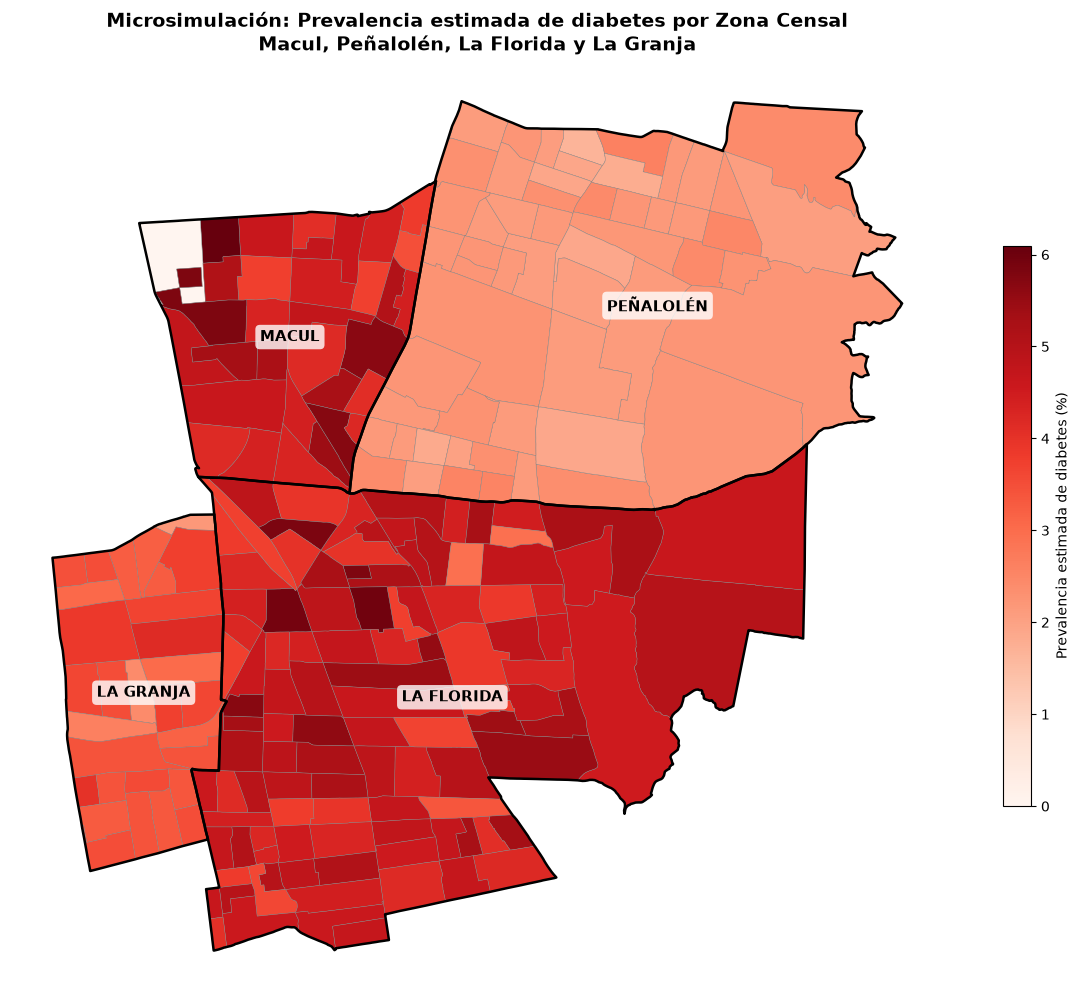

In [76]:
# 1. Asegurar que el índice de censo_zonal y de resultados_zona estén limpios y sean del mismo tipo
censo_zonal[ZONA_ID] = censo_zonal[ZONA_ID].astype(str).str.strip()
resultados_zona.index = resultados_zona.index.astype(str).str.strip()

# 2. Se unen los resultados a las geometrías zonales
zonas_mapa = censo_zonal.set_index(ZONA_ID).join(resultados_zona[["valor_zona"]])

# Convertir prevalencia a porcentaje (0 a 100)
zonas_mapa['valor_zona'] = zonas_mapa['valor_zona'] * 100

fig, ax = plt.subplots(figsize=(12, 10))

# Plotear las zonas censales con la prevalencia
zonas_mapa.plot(
    column="valor_zona",
    cmap="Reds", 
    linewidth=0.3,
    edgecolor="grey",
    legend=True,
    legend_kwds={'label': 'Prevalencia estimada de diabetes (%)', 'shrink': 0.6},
    missing_kwds={"color": "lightgrey", "label": "sin dato"},
    ax=ax,
)

# 3. Dibujar límites comunales por encima de las zonas
comunas_limites = censo_zonal.dissolve(by='COMUNA')
comunas_limites.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.8)

# 4. Agregar los nombres de las comunas 
for comuna, geom in comunas_limites.geometry.items():
    nombre_comuna = str(comuna).strip().upper()
    if 'PENAL' in nombre_comuna or 'PEÑAL' in nombre_comuna:
        label = "PEÑALOLÉN"
    else:
        label = nombre_comuna
        
    centroide = geom.representative_point()
    ax.text(
        centroide.x, centroide.y, label,
        fontsize=11, fontweight='bold', color='black',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none')
    )

ax.set_title("Microsimulación: Prevalencia estimada de diabetes por Zona Censal\nMacul, Peñalolén, La Florida y La Granja", fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

El mapa de prevalencia estimada de diabetes muestra una distribución claramente heterogénea en el área de estudio. Se observan zonas de baja prevalencia (0–2%), representadas en tonos amarillos y naranja claro, que se concentran principalmente en sectores de Macul. La prevalencia media (3–4%) abarca la mayor parte del territorio de La Florida y Peñalolén. Los focos de mayor prevalencia (5–6%), en tonos rojo oscuro, se localizan en La Granja y en el sur-oriente de La Florida. Esta heterogeneidad espacial evidencia que la carga de diabetes no se distribuye de forma uniforme, lo que motiva la necesidad de explorar los factores demográficos y socioeducativos que subyacen a estos patrones.

### 3.12 Selección de variables censales y codo (KMeans)

D:\anaconda3\envs\IDG\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\envs\IDG\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\envs\IDG\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\envs\IDG\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

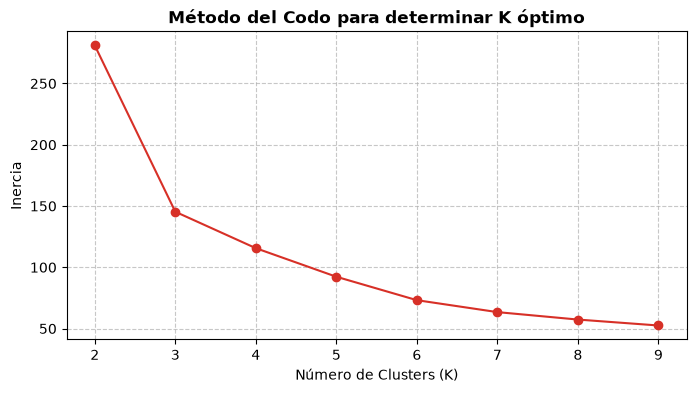

In [77]:
# 1. Se crea el df_cluster directamente desde censo_zonal para asegurar todas las columnas originales y la geometría
df_cluster = censo_zonal.copy()

# 2. Se asigna el valor de la microsimulación asegurando que coincida por índice
df_cluster['valor_zona'] = zonas_mapa['valor_zona']

# 3. Variable Adicional 1: Proporción de Adultos Mayores (Riesgo por Edad)
df_cluster['prop_adultos_mayores'] = np.where(
    df_cluster['n_per'] > 0, 
    df_cluster.get('n_edad_60_mas', 0) / df_cluster['n_per'] * 100, 
    0
)

# 4. Variable Adicional 2: Proporción de educación primaria o nula (Vulnerabilidad)
col_nunca = df_cluster.get('n_cine_nunca_curso_primera_infancia', 0)
col_prim = df_cluster.get('n_cine_primaria', 0)

df_cluster['prop_educ_baja'] = np.where(
    df_cluster['n_per'] > 0, 
    (col_nunca + col_prim) / df_cluster['n_per'] * 100, 
    0
)

# Se preparan las variables y rellenamos nulos por seguridad
X = df_cluster[['valor_zona', 'prop_adultos_mayores', 'prop_educ_baja']].fillna(0)

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Método del Codo
inercia = []
rango_k = range(2, 10)
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rango_k, inercia, marker='o', color='#d73027')
ax.set_title('Método del Codo para determinar K óptimo', fontweight='bold')
ax.set_xlabel('Número de Clusters (K)')
ax.set_ylabel('Inercia')
ax.set_xticks(rango_k)
ax.grid(True, linestyle='--', alpha=0.7)
plt.show()

El método del codo muestra una caída pronunciada de la inercia hasta K=3. A partir de K=4, la reducción se vuelve gradual, indicando que agregar más clusters no mejora sustancialmente la compactación de los grupos. Por ello, se selecciona K=4 como el número óptimo de clusters.

### 3.13 Perfiles y mapeo

--- PERFIL PROMEDIO DE CADA CLÚSTER (%) ---


D:\anaconda3\envs\IDG\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,valor_zona,prop_adultos_mayores,prop_educ_baja
cluster,,,
0,4.179469,22.484195,48.736978
1,4.596030,26.630346,32.178058
2,2.241562,21.330203,45.195581
3,3.854176,14.162575,26.444354


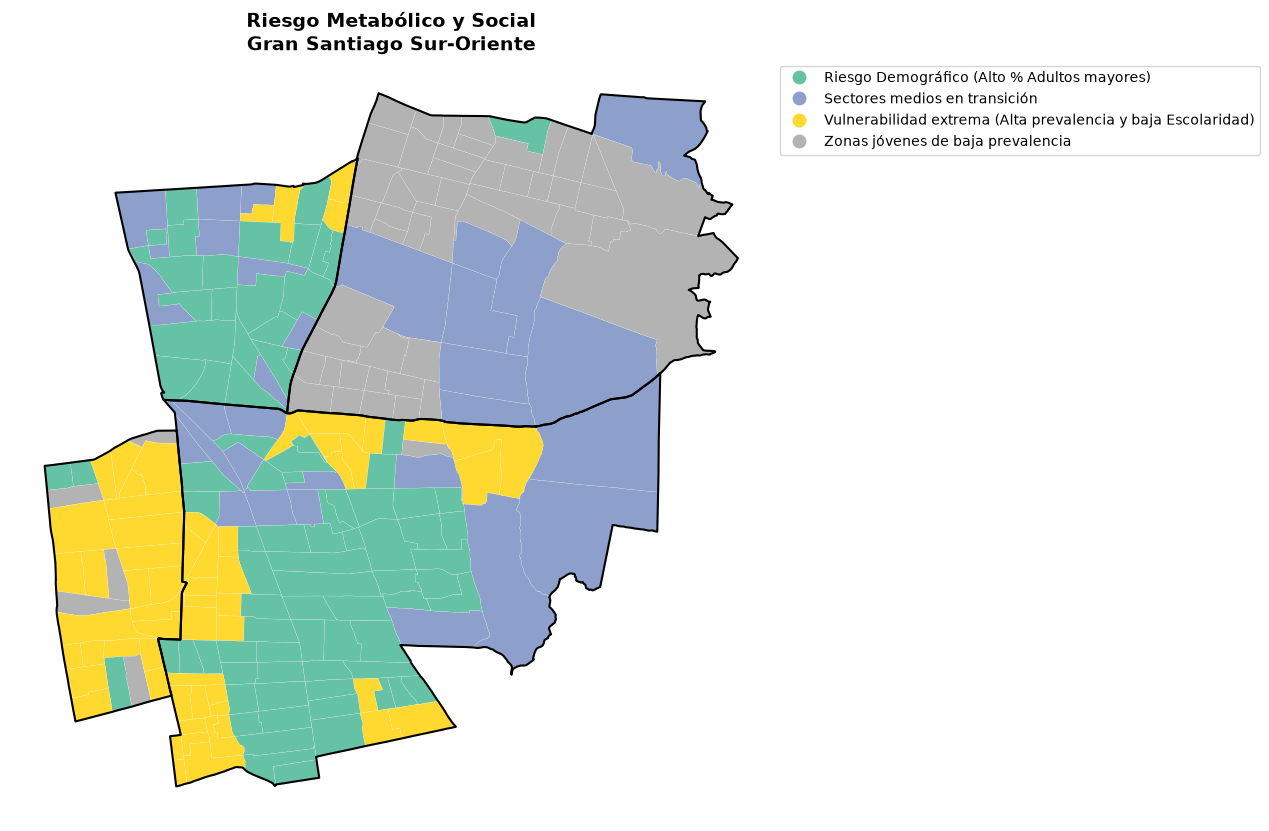

In [78]:
# 1. Se inicia de censo_zonal limpio y calculamos las variables demográficas directamente
df_cluster = censo_zonal.copy()

# Se calcula la proporción de adultos mayores
df_cluster['prop_adultos_mayores'] = np.where(
    df_cluster['n_per'] > 0, 
    df_cluster.get('n_edad_60_mas', 0) / df_cluster['n_per'] * 100, 
    0
)

# Se calcula la proporción de educación baja
col_nunca = df_cluster.get('n_cine_nunca_curso_primera_infancia', 0)
col_prim = df_cluster.get('n_cine_primaria', 0)
df_cluster['prop_educ_baja'] = np.where(
    df_cluster['n_per'] > 0, 
    (col_nunca + col_prim) / df_cluster['n_per'] * 100, 
    0
)

# 2. Se incorpora el valor de la microsimulación de diabetes usando el índice o ID de zona
zonas_temp = zonas_mapa.reset_index()
id_col = ZONA_ID if ZONA_ID in zonas_temp.columns else zonas_temp.columns[0]

# Se hace el merge limpio manteniendo todas las columnas necesarias
df_cluster = df_cluster.merge(
    zonas_temp[[id_col, 'valor_zona']], 
    on=id_col, 
    how='left'
)

# Si se generó duplicada con sufijo, se unifica:
if 'valor_zona_y' in df_cluster.columns:
    df_cluster['valor_zona'] = df_cluster['valor_zona_y']
    df_cluster = df_cluster.drop(columns=['valor_zona_x', 'valor_zona_y'])

# 3. Se preparan las variables para el modelo rellenando cualquier nulo por seguridad
X = df_cluster[['valor_zona', 'prop_adultos_mayores', 'prop_educ_baja']].fillna(0)

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Aplicar K-means con K óptimo
K_OP = 4
kmeans = KMeans(n_clusters=K_OP, random_state=SEED, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Mostrar el perfil de los clusters
perfil_clusters = df_cluster.groupby('cluster')[['valor_zona', 'prop_adultos_mayores', 'prop_educ_baja']].mean()
print("--- PERFIL PROMEDIO DE CADA CLÚSTER (%) ---")
display(perfil_clusters)

# 5. Etiquetas descriptivas de los clústeres
etiquetas = {
    0: 'Vulnerabilidad extrema (Alta prevalencia y baja Escolaridad)',
    1: 'Riesgo Demográfico (Alto % Adultos mayores)',
    2: 'Zonas jóvenes de baja prevalencia',
    3: 'Sectores medios en transición'
}
df_cluster['etiqueta_cluster'] = df_cluster['cluster'].map(etiquetas)

# 6. Mapeo de Clústeres
fig, ax = plt.subplots(figsize=(12, 10))
df_cluster.plot(column='etiqueta_cluster', categorical=True, cmap='Set2',
                linewidth=0.1, edgecolor='white', legend=True,
                legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)}, ax=ax)

# Dibujar Límites comunales
comunas_limites.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

ax.set_title('Riesgo Metabólico y Social\nGran Santiago Sur-Oriente', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

### ***Interpretación de clusters***
**Cluster 0 – Vulnerabilidad social con baja prevalencia:**
Tiene la mayor proporción de educación baja (46%) y un envejecimiento moderado (21%), pero la prevalencia de diabetes es la más baja (2.2%). Esto podría indicar zonas con condiciones socioeconómicas desfavorables pero donde la diabetes está subdiagnosticada o donde la población es relativamente joven dentro de los adultos mayores. Es un perfil contradictorio que merece atención.

**Cluster 1 – Riesgo demográfico y metabólico:**
Presenta la mayor prevalencia (4.46%) y la mayor proporción de adultos mayores (26.5%), con un nivel intermedio de educación baja (32.4%). Este grupo concentra el riesgo asociado al envejecimiento, que es un factor de riesgo establecido para la diabetes.

**Cluster 2 – Vulnerabilidad social con alta prevalencia:**
Similar al cluster 0 en educación baja (48.9%) y envejecimiento (22.5%), pero con una prevalencia mucho más alta (4.25%). Esto sugiere que, dentro de las zonas vulnerables, hay diferencias en la carga de enfermedad que podrían estar relacionadas con el acceso a servicios de salud, hábitos de vida u otros factores no medidos.

**Cluster 3 – Sectores jóvenes y más educados:**
Tiene la menor proporción de adultos mayores (14.2%) y la menor educación baja (26.4%), y su prevalencia es intermedia (3.84%). Corresponde a zonas con mejores condiciones socioeconómicas y menor envejecimiento, lo que se asocia a un menor riesgo.

### 3.14 Índice de Shannon

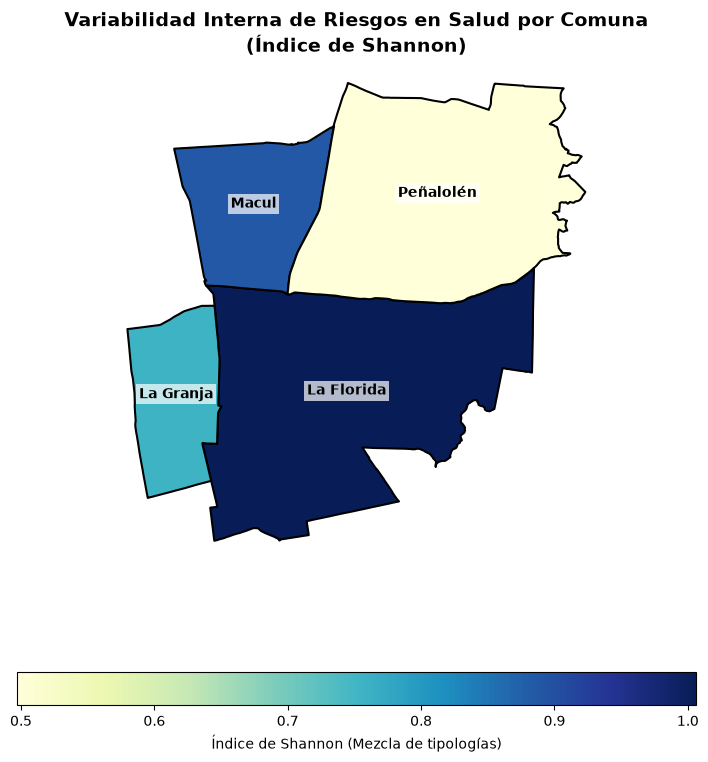

--- ÍNDICE DE SHANNON POR COMUNA ---


,COMUNA,shannon_idx
0,LA FLORIDA,1.006018
2,MACUL,0.886941
1,LA GRANJA,0.756332
3,PEÑALOLÉN,0.496915


In [79]:
# 1. Cálculo del Índice de Shannon
cluster_counts = df_cluster.groupby(['COMUNA', 'cluster']).size().unstack(fill_value=0)
cluster_props = cluster_counts.div(cluster_counts.sum(axis=1), axis=0)
shannon_index = cluster_props.apply(lambda row: entropy(row, base=np.e), axis=1)
shannon_df = shannon_index.reset_index(name='shannon_idx')

geom_comunas = comunas_limites.copy().reset_index()
geom_col_name = comunas_limites.geometry.name
geom_comunas = geom_comunas[['COMUNA', geom_col_name]].rename(columns={geom_col_name: 'geometry'})

# 3. Se realiza merge y se fuerza el GeoDataFrame
mapa_comunal = geom_comunas.merge(shannon_df, on='COMUNA')
mapa_comunal = gpd.GeoDataFrame(mapa_comunal, geometry='geometry')

# 4. Mapa del Índice de Shannon
fig, ax = plt.subplots(figsize=(10, 8))
mapa_comunal.plot(
    column='shannon_idx', cmap='YlGnBu', linewidth=1.5, edgecolor='black',
    legend=True, legend_kwds={'label': "Índice de Shannon (Mezcla de tipologías)", 'orientation': "horizontal", 'shrink': 0.7}, ax=ax
)

# 5. Nombres de las comunas en el mapa
for idx, row in mapa_comunal.iterrows():
    centroide = row['geometry'].centroid
    ax.annotate(text=str(row['COMUNA']).title(), 
                xy=(centroide.x, centroide.y),
                horizontalalignment='center', fontsize=10, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

ax.set_title('Variabilidad Interna de Riesgos en Salud por Comuna\n(Índice de Shannon)', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("--- ÍNDICE DE SHANNON POR COMUNA ---")
display(mapa_comunal[['COMUNA', 'shannon_idx']].sort_values(by='shannon_idx', ascending=False))

Los resultados muestran que **La Florida** presenta el índice más alto (1.006), lo que refleja una alta heterogeneidad interna. Esta comuna combina zonas de vulnerabilidad extrema (Cluster 0), riesgo demográfico (Cluster 1), sectores jóvenes (Cluster 2) y áreas en transición (Cluster 3). Esto implica que las políticas de salud en La Florida deben ser diferenciadas por zona, adaptándose a las características específicas de cada territorio.

En contraste, **Peñalolén** presenta el índice más bajo (0.497), indicando una mayor homogeneidad, probablemente dominada por el Cluster 1 (Riesgo Demográfico). Esto sugiere que en Peñalolén las intervenciones pueden ser más uniformes, focalizadas en el manejo de enfermedades crónicas y atención a adultos mayores.

**Macul** (0.887) y **La Granja** (0.756) presentan niveles intermedios de heterogeneidad. Macul parece estar dominada por clusters de población joven y educada (Clusters 2 y 3), mientras que La Granja combina vulnerabilidad social y riesgo demográfico (Clusters 0 y 1).

La utilidad de este índice radica en que permite a los planificadores territoriales decidir si diseñar estrategias uniformes (en comunas homogéneas) o diferenciadas por zona (en comunas heterogéneas), optimizando así la asignación de recursos y la efectividad de las intervenciones.

## 3.15 Análisis de correlación entre variables

Como paso final del análisis exploratorio, se calculó la correlación de Pearson entre las tres variables utilizadas en el agrupamiento: Prevalencia de diabetes microsimulada, proporción de adultos mayores y proporción de educación baja.

Los objetivos fueron, primeramente, evaluar el grado de asociación lineal entre las variables a nivel global, identificando posibles redundancias que pudieran afectar la estructura de los clusters, y después examinar si estas relaciones se mantienen o se modifican al interior de cada cluster, lo que permite entender cómo operan los determinantes de la diabetes en distintos contextos territoriales.

A continuación se presentan la matriz de correlación global y las matrices por cluster, junto con su interpretación.

#### Análisis de correlación entre variables


--- MATRIZ DE CORRELACIÓN DE PEARSON ---
                      valor_zona  prop_adultos_mayores  prop_educ_baja
valor_zona                 1.000                 0.286          -0.256
prop_adultos_mayores       0.286                 1.000          -0.001
prop_educ_baja            -0.256                -0.001           1.000


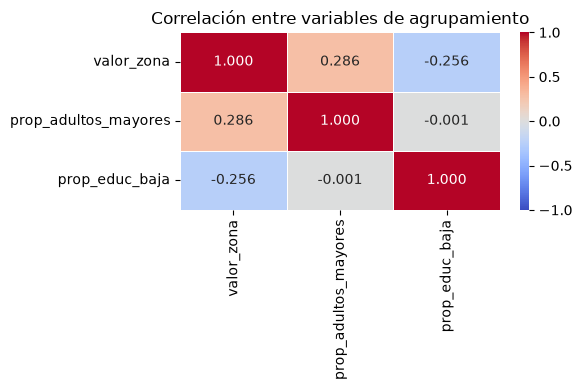

In [80]:
# --- MATRIZ DE CORRELACIÓN DE PEARSON ---
# Calcular la matriz de correlación
corr_matrix = X.corr(method='pearson')

print("\n--- MATRIZ DE CORRELACIÓN DE PEARSON ---")
print(corr_matrix.to_string(float_format="%.3f"))

# Visualización con mapa de calor
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f', linewidths=0.5, ax=ax)
ax.set_title('Correlación entre variables de agrupamiento')
plt.tight_layout()
plt.show()

- **Prevalencia de diabetes vs. Proporción de adultos mayores (r = 0.286)**: Se observa una correlación positiva baja. Esto confirma la asociación esperada entre el envejecimiento y la mayor carga de diabetes, aunque la magnitud moderada sugiere que la edad, si bien es un factor relevante, no es el único determinante de la distribución territorial de la enfermedad. Otros factores (como el acceso a salud o los estilos de vida) también juegan un papel importante.

- **Prevalencia de diabetes vs. Proporción de educación baja (r = -0.256)**: Se observa una correlación negativa baja, un resultado contraintuitivo, ya que la literatura sugiere que menor nivel socioeconómico suele asociarse a mayor prevalencia de enfermedades crónicas. Este hallazgo puede explicarse por varias hipótesis:

  - En zonas con baja escolaridad podría existir un subdiagnóstico de diabetes debido a menor acceso a controles preventivos. 
  - Podría haber un efecto de composición poblacional no captado por la edad, donde la educación baja esté concentrada en sectores con otras características protectoras.
  - La variable de educación baja, al ser un agregado zonal, podría no reflejar la relación a nivel individual. La correlación negativa observada a nivel general no necesariamente se mantiene de la misma forma en todos los territorios. Por ello, el clustering permite identificar grupos de zonas con características similares y analizar cómo se relacionan estas variables dentro de cada grupo.

- **Proporción de adultos mayores vs. Proporción de educación baja (r = -0.001)**: La correlación es prácticamente nula, lo que indica que ambas variables no presentan una relación significativa entre sí y aportan información diferente al análisis. Mientras la proporción de adultos mayores representa una característica demográfica asociada al envejecimiento de la población, la proporción de educación baja refleja una dimensión social del territorio. Por lo tanto, ambas variables permiten incorporar características complementarias en la formación de los clusters.

En conjunto, estos resultados justifican el uso de las tres variables en el análisis de agrupamiento, ya que presentan relaciones débiles a moderadas y aportan información complementaria sobre el territorio.

#### Correlación dentro de cada cluster

In [81]:
# --- CORRELACIÓN DENTRO DE CADA CLUSTER ---
print("\n--- CORRELACIÓN DE PEARSON DENTRO DE CADA CLÚSTER ---")
for cluster_id in sorted(df_cluster['cluster'].unique()):
    # Obtener el nombre de la etiqueta si existe
    etiqueta = etiquetas.get(cluster_id, f"Cluster {cluster_id}")
    
    # Filtrar el subset
    subset = df_cluster[df_cluster['cluster'] == cluster_id]
    
    # Calcular correlación
    corr_sub = subset[['valor_zona', 'prop_adultos_mayores', 'prop_educ_baja']].corr()
    
    print(f"\n--- Cluster {cluster_id}: {etiqueta} ---")
    print(f"Número de zonas: {len(subset)}")
    print(corr_sub.to_string(float_format="%.3f"))


--- CORRELACIÓN DE PEARSON DENTRO DE CADA CLÚSTER ---

--- Cluster 0: Vulnerabilidad extrema (Alta prevalencia y baja Escolaridad) ---
Número de zonas: 60
                      valor_zona  prop_adultos_mayores  prop_educ_baja
valor_zona                 1.000                -0.133          -0.081
prop_adultos_mayores      -0.133                 1.000          -0.008
prop_educ_baja            -0.081                -0.008           1.000

--- Cluster 1: Riesgo Demográfico (Alto % Adultos mayores) ---
Número de zonas: 83
                      valor_zona  prop_adultos_mayores  prop_educ_baja
valor_zona                 1.000                 0.084           0.021
prop_adultos_mayores       0.084                 1.000          -0.088
prop_educ_baja             0.021                -0.088           1.000

--- Cluster 2: Zonas jóvenes de baja prevalencia ---
Número de zonas: 53
                      valor_zona  prop_adultos_mayores  prop_educ_baja
valor_zona                 1.000               

-------------------------------------------------------------
El análisis de correlación al interior de cada cluster permite identificar si las relaciones entre las variables se mantienen o cambian según el perfil territorial. Los resultados muestran diferencias entre los grupos:

- **Cluster 0 (Vulnerabilidad educativa con baja prevalencia, n=60 zonas):** Las correlaciones son muy bajas, indicando que dentro de este grupo no existe una relación clara entre la prevalencia de diabetes, la edad y la educación.

- **Cluster 1 (Riesgo demográfico, n=83 zonas):** Las correlaciones también son muy débiles. A pesar de presentar una mayor proporción de adultos mayores, esta variable no muestra una relación clara con la prevalencia de diabetes dentro del cluster.

- **Cluster 2 (Zonas jóvenes de baja prevalencia, n=53 zonas):** Se observan relaciones muy débiles entre la prevalencia y las demás variables. La correlación entre adultos mayores y educación baja es negativa (r = -0,270), indicando que ambas características tienden a variar en sentidos opuestos dentro de este grupo.

- **Cluster 3 (Sectores medios en transición, n=30 zonas):** Presenta las correlaciones más altas, con relaciones positivas entre las tres variables. Esto indica que, dentro de este grupo, una mayor proporción de adultos mayores y de educación baja tiende a asociarse con una mayor prevalencia de diabetes.

En conjunto, los resultados muestran que las relaciones entre las variables no son iguales en todo el territorio. Mientras el Cluster 3 presenta una asociación más clara entre envejecimiento, educación y prevalencia de diabetes, en los demás grupos estas relaciones son débiles o prácticamente inexistentes. Esto demuestra que el clustering permite identificar perfiles territoriales donde los factores asociados a la diabetes presentan comportamientos diferentes.

------------------------------------

### 4. Conclusiones
El presente trabajo cumplió su objetivo de microsimular la prevalencia de diabetes a nivel de zona censal en el sector suroriente del Gran Santiago, integrando esta información con variables demográficas y socioeducativas para identificar perfiles territoriales diferenciados.

La microsimulación permitió obtener una representación espacial más detallada de la prevalencia de diabetes que la disponible directamente en la encuesta CASEN, evidenciando una distribución heterogénea, con mayores concentraciones en sectores de La Granja y el sur de La Florida. A partir del análisis de clustering se identificaron cuatro perfiles territoriales, demostrando que la distribución de la enfermedad presenta características diferentes según las condiciones demográficas y socioeducativas de cada zona.

Los resultados muestran que una mayor vulnerabilidad educativa no se relaciona necesariamente con una mayor prevalencia de diabetes, ya que algunos clusters presentan niveles educativos similares, pero diferencias importantes en la prevalencia. Por su parte, el Cluster 1, caracterizado por una mayor proporción de adultos mayores, presenta un perfil asociado al riesgo demográfico. El Cluster 3 destaca por presentar las relaciones más claras entre edad, educación y prevalencia de diabetes, diferenciándose del comportamiento observado en los demás grupos.

El Índice de Shannon permitió complementar este análisis al identificar diferencias en la heterogeneidad interna de las comunas. La Florida presenta una mayor diversidad de perfiles territoriales, lo que sugiere la necesidad de considerar estrategias diferenciadas dentro de la propia comuna. En contraste, Peñalolén presenta una estructura más homogénea, por lo que las intervenciones podrían presentar un mayor grado de uniformidad.

Asimismo, el análisis de correlación evidenció que las relaciones entre las variables no son homogéneas en todo el territorio. Mientras el Cluster 3 presenta asociaciones más claras entre las variables analizadas, en los demás clusters estas relaciones son débiles o prácticamente inexistentes. Esto refuerza la utilidad del clustering para identificar territorios con características y comportamientos diferenciados.

En definitiva, la combinación de microsimulación, clustering e Índice de Shannon permitió obtener una visión territorial más detallada de la distribución de la diabetes. Los resultados pueden contribuir a una focalización más precisa de las estrategias de salud, considerando las características particulares de cada perfil territorial y favoreciendo una asignación de recursos acorde con las necesidades de cada zona.